# Kjemiske biblioteker

```{admonition} Læringsutbytte
Etter å ha arbeidet med dette temaet, skal du kunne:

1. hente og utforske grunnstoffdata med `mendeleev`
2. hente data om kjemiske forbindelser fra PubChem med `pubchempy`
3. representere molekyler fra SMILES og beregne molekylegenskaper med `RDKit`
4. balansere en reaksjonslikning ved å løse et lineært likningssystem
5. vurdere når et bibliotek er nyttig, og når det er mer hensiktsmessig å skrive koden selv
```

Python har et stort antall biblioteker, og flere av dem er utviklet spesielt for kjemi. I dette kapitlet skal vi se på noen biblioteker som gir tilgang til kjemiske data, molekylstrukturer og numeriske beregninger.

Når vi vurderer om et bibliotek er nyttig, kan vi spørre hva det tilfører programmet vårt. Biblioteker er særlig verdifulle når de gir tilgang til:

1. **Data:** kuraterte og kvalitetssikrede verdier, for eksempel ioniseringsenergier og atomradier
2. **Algoritmer og visualisering:** funksjonalitet som er omfattende eller krevende å programmere selv
3. **Standardisering:** filformater og konvensjoner som gjør det mulig å utveksle data mellom ulike programmer

For enkle faglige beregninger kan det derimot være mer lærerikt å skrive funksjonene selv. Da blir sammenhengen mellom kjemien og programkoden tydeligere, og koden kan lettere tilpasses nye problemstillinger.

Kapitlet er organisert etter hva bibliotekene brukes til:

| Del | Bruksområde | Eksempler |
|---|---|---|
| 1 | Kjemiske data | `mendeleev`, `pubchempy` |
| 2 | Struktur og representasjon | `RDKit` |
| 3 | Beregninger vi kan programmere selv | støkiometri og balansering |


## Installasjon

Før du kjører eksemplene, må bibliotekene installeres. Kjør kodecellen nedenfor én gang. Utropstegnet gjør at kommandoen sendes til pakkebehandleren `pip`, i stedet for å bli tolket som vanlig Python-kode.


In [ ]:
!pip install mendeleev pubchempy rdkit sympy

## Biblioteker som gir tilgang til data

### Mendeleev

Periodesystemet kan behandles som et stort datasett. Egenskaper som elektronegativitet, ioniseringsenergi og atomradius er samlet fra målinger og modeller, og de kan ikke beregnes direkte med noen få linjer kode. Biblioteket `mendeleev` gir oss tilgang til slike grunnstoffdata.

Grunnenheten i biblioteket er klassen `element`. En klasse kan betraktes som en oppskrift for å opprette objekter. Alle grunnstoffobjektene har de samme typene egenskaper, men verdiene varierer fra grunnstoff til grunnstoff.


In [2]:
from mendeleev import element

svovel = element("S")          # Eller: element(16)

print(svovel.name)
print(svovel.symbol)
print(svovel.atomic_number)
print(svovel.atomic_weight)
print(svovel.block, svovel.period, svovel.group_id)


Sulfur
S
16
32.06
p 3 16


Elektronegativitet hentes med et *metodekall*, ikke som en vanlig egenskap. Grunnen er at elektronegativitet kan defineres ved hjelp av flere skalaer. Vi må derfor angi hvilken skala vi vil bruke.


In [3]:
print("Pauling: ", svovel.electronegativity("pauling"))
print("Allen:   ", svovel.electronegativity("allen"))
print("Mulliken:", svovel.electronegativity("mulliken"))


Pauling:  2.58
Allen:    15.31
Mulliken: 6.218557015


```{admonition} Underveisoppgave: Hvorfor er tallene så forskjellige?
:class: tip

De tre skalaene gir svært ulike tallverdier for svovel.

Slå opp definisjonene av skalaene. Hvilken enhet brukes i hvert tilfelle? Hvorfor kan tallene ikke sammenliknes direkte, og hva må vi gjøre før en sammenlikning blir meningsfull?
```

````{admonition} Løsningsforslag
:class: tip, dropdown

Paulings skala er enhetsløs og er definert ut fra bindingsenergier. Allens og Mullikens skalaer bygger derimot på energistørrelser og oppgis i elektronvolt (eV).

Tallverdiene kan derfor ikke sammenliknes direkte. Det som kan sammenliknes, er blant annet rekkefølgen grunnstoffene får på hver skala, eller relative forskjeller etter at skalaene er normert til samme intervall.

Dette illustrerer et generelt poeng: En tallverdi fra et bibliotek må alltid tolkes sammen med definisjonen og enheten som hører til.
````


#### Flere grunnstoffer med lister

Vi trenger ikke hente hele periodesystemet som en tabell for å undersøke en enkel trend. I stedet kan vi lage ei liste med grunnstoffsymboler og hente ett grunnstoff om gangen.

Dette bygger på lister og løkker, som vi allerede kjenner. Det gjør også koden lettere å lese: Vi ser tydelig hvilke grunnstoffer som er med, og hvilke egenskaper vi henter.

In [4]:
# Grunnstoffene i andre periode
symboler = ["Li", "Be", "B", "C", "N", "O", "F", "Ne"]

for symbol in symboler:
    grunnstoff = element(symbol)
    print(symbol, grunnstoff.atomic_number, grunnstoff.atomic_weight)

Li 3 6.94
Be 4 9.0121831
B 5 10.81
C 6 12.011
N 7 14.007
O 8 15.999
F 9 18.998403163
Ne 10 20.1797


#### Manglende verdier

Et bibliotek har ikke nødvendigvis en verdi for alle egenskaper til alle grunnstoffer. Dersom en verdi mangler, får vi ofte `None`.

Vi bør derfor kontrollere verdien før vi bruker den i en beregning eller et plott.

In [5]:
symboler_uten_verdi = []

for atomnummer in range(1, 119):
    grunnstoff = element(atomnummer)
    elektronegativitet = grunnstoff.electronegativity("pauling")

    if elektronegativitet is None:
        symboler_uten_verdi.append(grunnstoff.symbol)

print("Grunnstoff uten Pauling-elektronegativitet:")
print(symboler_uten_verdi)

Grunnstoff uten Pauling-elektronegativitet:
['He', 'Ne', 'Ar', 'Kr', 'Pm', 'Eu', 'Tb', 'Yb', 'Rn', 'Am', 'Cm', 'Bk', 'Cf', 'Es', 'Fm', 'Md', 'No', 'Lr', 'Rf', 'Db', 'Sg', 'Bh', 'Hs', 'Mt', 'Ds', 'Rg', 'Cn', 'Nh', 'Fl', 'Mc', 'Lv', 'Ts', 'Og']


```{admonition} Underveisoppgave: Hvilke verdier mangler?
:class: tip

Studer lista ovenfor.

1. Én gruppe i periodesystemet er tydelig representert. Hvilken gruppe er dette, og hva kan være den kjemiske forklaringen?
2. Flere av de tyngste grunnstoffene mangler også verdier. Hvorfor er det vanskelig å bestemme kjemiske egenskaper for disse?
3. Lag to lister: én med atomnummer og én med Pauling-elektronegativitet. Legg bare til grunnstoffer som faktisk har en verdi, og lag deretter et spredningsplott.
```

````{admonition} Løsningsforslag
:class: tip, dropdown

1. **Edelgassene** er tydelig representert. Paulings skala bygger på bindingsenergier, og edelgassene danner få vanlige bindinger.
2. Mange av de tyngste grunnstoffene er framstilt i svært små mengder og har korte halveringstider. Det gjør målinger vanskelige.
3. Vi kan kontrollere verdien med en `if`-test før vi legger den til i listene:

```{code-block} python
import matplotlib.pyplot as plt

atomnumre = []
elektronegativiteter = []

for atomnummer in range(1, 119):
    grunnstoff = element(atomnummer)
    verdi = grunnstoff.electronegativity("pauling")

    if verdi is not None:
        atomnumre.append(atomnummer)
        elektronegativiteter.append(verdi)

plt.scatter(atomnumre, elektronegativiteter)
plt.xlabel("Atomnummer")
plt.ylabel("Elektronegativitet (Pauling)")
plt.show()
```
````

#### Trender innenfor en periode

For andre periode kan vi bruke symbolene direkte på x-aksen. Da slipper vi både tabellbehandling og ekstra kode for å skrive symbolene ved hvert punkt.

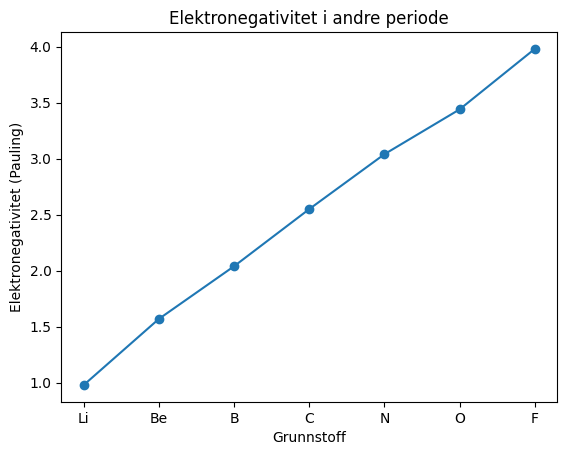

In [6]:
import matplotlib.pyplot as plt

symboler = ["Li", "Be", "B", "C", "N", "O", "F"]
elektronegativiteter = []

for symbol in symboler:
    grunnstoff = element(symbol)
    verdi = grunnstoff.electronegativity("pauling")
    elektronegativiteter.append(verdi)

plt.plot(symboler, elektronegativiteter, marker="o")
plt.xlabel("Grunnstoff")
plt.ylabel("Elektronegativitet (Pauling)")
plt.title("Elektronegativitet i andre periode")
plt.show()

```{admonition} Underveisoppgave: Forklar to trender
:class: tip

1. Beskriv trenden fra litium til fluor og forklar den ut fra kjerneladning og skjerming.
2. Lag et tilsvarende plott for halogenene med lista `["F", "Cl", "Br", "I"]`.
3. Går trenden samme vei nedover i ei gruppe som bortover i en periode? Forklar forskjellen.
```

````{admonition} Løsningsforslag
:class: tip, dropdown

Elektronegativiteten øker fra litium til fluor. Kjerneladningen øker, mens elektronene legges i det samme hovedskallet. Effektiv kjerneladning øker derfor, og valenselektronene holdes sterkere.

Nedover i ei gruppe minker elektronegativiteten. Valenselektronene befinner seg lenger fra kjernen og skjermes av flere indre elektronskall.

```{code-block} python
halogener = ["F", "Cl", "Br", "I"]
verdier = []

for symbol in halogener:
    grunnstoff = element(symbol)
    verdier.append(grunnstoff.electronegativity("pauling"))

plt.plot(halogener, verdier, marker="o")
plt.xlabel("Grunnstoff")
plt.ylabel("Elektronegativitet (Pauling)")
plt.show()
```
````

`mendeleev` inneholder langt mer enn elektronegativitet: ioniseringsenergier, ioneradier, isotoper, oksidensjonstall og en del til. Du får en oversikt over alt som er registrert for ett grunnstoff ved å skrive objektet i en egen celle.


In [7]:
# Ioniseringsenergier er en dictionary med ioniseringsgrad som nøkkel
natrium = element("Na")
print("1. ioniseringsenergi:", natrium.ionenergies[1], "eV")
print("2. ioniseringsenergi:", natrium.ionenergies[2], "eV")

# Skriv objektet alene i en celle for å se alt som finnes:
# natrium


1. ioniseringsenergi: 5.13907696 eV
2. ioniseringsenergi: 47.28636 eV


```{admonition} Underveisoppgave: Det store spranget
:class: tip

Hent ut de fem første ioniseringsenergiene til magnesium og plott dem mot ioniseringsgrad.

Hvor kommer det store spranget, og hvorfor akkurat der? Hva forteller dette om elektronstrukturen til magnesium?
```

````{admonition} Løsningsforslag
:class: tip, dropdown

```{code-block} python
magnesium = element("Mg")

grader = [1, 2, 3, 4, 5]
energier = []

for grad in grader:
    energier.append(magnesium.ionenergies[grad])

plt.plot(grader, energier, marker="o")
plt.xlabel("Ioniseringsgrad")
plt.ylabel("Ioniseringsenergi (eV)")
plt.show()
```

Spranget kommer mellom den andre og den tredje ioniseringen. De to første elektronene tas fra 3s-orbitalen. Det tredje må tas fra et fylt indre skall og krever derfor mye mer energi.
````

### PubChemPy

PubChem er en åpen database med informasjon om kjemiske forbindelser. Biblioteket `pubchempy` kommuniserer med PubChem gjennom et API og gjør dataene tilgjengelige som Python-objekter.

I motsetning til `mendeleev` henter `pubchempy` data over internett mens koden kjører. Det betyr at du må ha nettilgang, og at mange gjentatte oppslag kan ta tid. Når det er mulig, bør resultatene lagres lokalt og brukes på nytt.


In [9]:
import pubchempy as pcp

treff = pcp.get_compounds("paracetamol", "name")
paracetamol = treff[0]

print("PubChem CID: ", paracetamol.cid)
print("Molekylformel:", paracetamol.molecular_formula)
print("Molar masse:  ", paracetamol.molecular_weight, "g/mol")
print("IUPAC-navn:   ", paracetamol.iupac_name)


PubChem CID:  1983
Molekylformel: C8H9NO2
Molar masse:   151.16 g/mol
IUPAC-navn:    N-(4-hydroxyphenyl)acetamide


```{admonition} Nettbaserte API-er kan endres
:class: warning

Nettbaserte tjenester og API-er kan endres over tid. Dersom et attributt eller et kodeeksempel slutter å virke, bør du kontrollere den oppdaterte dokumentasjonen for både `pubchempy` og PubChem.

Dette er en vanlig del av arbeid med programkode som henter data fra eksterne tjenester. Dokumentasjonen er derfor en viktig del av verktøyet.
```


In [13]:
navn_liste = ["caffeine", "aspirin", "ibuprofen", "ascorbic acid"]

for navn in navn_liste:
    forbindelse = pcp.get_compounds(navn, "name")[0]
    print(navn)
    print("  CID:", forbindelse.cid)
    print("  Formel:", forbindelse.molecular_formula)
    print("  Molar masse:", forbindelse.molecular_weight, "g/mol")

caffeine
  CID: 2519
  Formel: C8H10N4O2
  Molar masse: 194.19 g/mol
aspirin
  CID: 2244
  Formel: C9H8O4
  Molar masse: 180.16 g/mol
ibuprofen
  CID: 3672
  Formel: C13H18O2
  Molar masse: 206.28 g/mol
ascorbic acid
  CID: 54670067
  Formel: C6H8O6
  Molar masse: 176.12 g/mol


```{admonition} Underveisoppgave: Hent flere forbindelser
:class: tip

Lag ei liste med fem legemidler eller naturstoffer. Bruk en løkke til å hente molekylformel, molar masse og CID for hvert stoff, og skriv verdiene ut på en ryddig måte.

Ta vare på CID-ene. Du får bruk for dem når vi skal visualisere molekylene.
```

````{admonition} Løsningsforslag
:class: tip, dropdown

```{code-block} python
navn_liste = ["koffein", "nikotin", "morfin", "penicillin G", "kolesterol"]

for navn in navn_liste:
    forbindelse = pcp.get_compounds(navn, "name")[0]
    print(navn, forbindelse.cid, forbindelse.molecular_formula,
          forbindelse.molecular_weight)
```
````

## Biblioteker for struktur og representasjon

### RDKit

`RDKit` er et mye brukt bibliotek innen kjemi. Det arbeider med selve molekylstrukturen, ikke bare med molekylformelen. Biblioteket kan blant annet lese strukturkoder, identifisere bindinger og ringer, tegne strukturformler, søke etter strukturmønstre og generere tredimensjonale konformasjoner.

RDKit gjør det også mulig å bevege seg mellom ulike representasjoner av den samme forbindelsen:

- **Symbolsk:** SMILES-koden `CCO` representerer etanol.
- **Todimensjonal:** RDKit kan tegne en strukturformel.
- **Tredimensjonal:** biblioteket kan generere en konformasjon med bindingslengder og vinkler.
- **Beregnete egenskaper:** strukturen kan brukes til å beregne størrelser som molar masse, løselighet og polart overflateareal.

Representasjonene viser ulike sider av den samme forbindelsen.

#### SMILES

SMILES (Simplified Molecular Input Line Entry System) er en metode for å skrive en molekylstruktur som tekst. Noen grunnleggende regler er:

- Atomer skrives med grunnstoffsymbol. Hydrogenatomer utelates vanligvis og legges til automatisk.
- Tegn ved siden av hverandre angir bindinger: `CCO` representerer etanol.
- `=` angir dobbeltbinding, mens `#` angir trippelbinding.
- Parenteser brukes for sidegrupper: `CC(C)C` representerer 2-metylpropan.
- Tall brukes til å lukke ringer: `C1CCCCC1` representerer sykloheksan.
- Små bokstaver brukes for aromatiske atomer: `c1ccccc1` representerer benzen.

SMILES for kjente forbindelser kan du også hente fra Pubchempy-biblioteket:

In [19]:
import pubchempy as pcp

c = pcp.get_compounds("aspirin", "name")[0]
print(c.smiles)

CC(=O)OC1=CC=CC=C1C(=O)O


Her er eksempel på hvordan vi kan brukes SMILES i Rdkit:

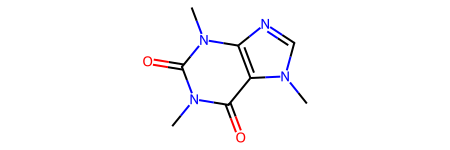

In [1]:
from rdkit import Chem
from rdkit.Chem import Draw, Descriptors, AllChem
from rdkit.Chem.Draw import IPythonConsole   # gjør at molekyler tegnes automatisk

koffein = Chem.MolFromSmiles("CN1C=NC2=C1C(=O)N(C)C(=O)N2C")
koffein


````{admonition} Kontroller at innlesingen lyktes
:class: warning

`Chem.MolFromSmiles` returnerer `None` dersom SMILES-koden ikke er gyldig. Hvis denne verdien sendes videre til en annen funksjon, kan feilmeldingen oppstå et annet sted i programmet og bli vanskelig å tolke.

Det er derfor lurt å kontrollere resultatet:

```{code-block} python
molekyl = Chem.MolFromSmiles(smiles)
if molekyl is None:
    print("Ugyldig SMILES:", smiles)
```
````

#### Flere molekyler samtidig

Når vi skal arbeide med flere molekyler, kan vi lagre navn og SMILES-koder i en **dictionary**. Nøkkelen er navnet på forbindelsen, og verdien er SMILES-koden.

I løkka nedenfor skjer dette trinn for trinn:

1. `for stoffnavn in smiles` går gjennom nøklene i dictionariet.
2. `smiles[stoffnavn]` henter SMILES-koden som hører til navnet.
3. `Chem.MolFromSmiles(...)` gjør teksten om til et RDKit-molekyl.
4. Molekylene og navnene legges i hver sin liste.
5. `Draw.MolsToGridImage` bruker de to listene til å lage et rutenett med strukturformler og navn.

Det er vanlig at et bibliotek krever data i en bestemt form. Her må RDKit få **ei liste med molekylobjekter** og **ei liste med merkelapper**.

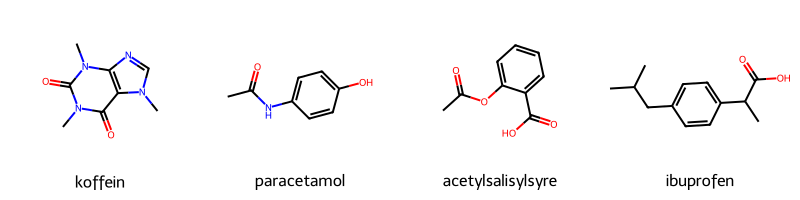

In [14]:
smiles = {
    "koffein": "CN1C=NC2=C1C(=O)N(C)C(=O)N2C",
    "paracetamol": "CC(=O)Nc1ccc(O)cc1",
    "acetylsalisylsyre": "CC(=O)Oc1ccccc1C(=O)O",
    "ibuprofen": "CC(C)Cc1ccc(cc1)C(C)C(=O)O",
}

molekyler = []
navn = []

for stoffnavn in smiles:
    molekyl = Chem.MolFromSmiles(smiles[stoffnavn])
    molekyler.append(molekyl)
    navn.append(stoffnavn)

Draw.MolsToGridImage(molekyler, legends=navn, molsPerRow=4)

#### Fra struktur til egenskap

Når RDKit har lest inn en struktur, kan biblioteket beregne en rekke **molekyldeskriptorer**. En deskriptor er et tall som beskriver en bestemt egenskap ved molekylet.

I koden nedenfor bruker vi funksjoner fra `Descriptors`. Alle funksjonene får et RDKit-molekyl som argument:

| Funksjon | Hva den gir |
|---|---|
| `Descriptors.MolWt(molekyl)` | beregnet molar masse |
| `Descriptors.MolLogP(molekyl)` | estimert logP, et mål på lipofilitet |
| `Descriptors.TPSA(molekyl)` | topologisk polart overflateareal |
| `Descriptors.NumHDonors(molekyl)` | antall H-bindingsdonorer |
| `Descriptors.NumHAcceptors(molekyl)` | antall H-bindingsakseptorer |

Legg merke til mønsteret: `bibliotek.funksjon(argument)`. Først angir vi hvor funksjonen kommer fra (`Descriptors`), deretter hvilken funksjon vi bruker, og til slutt hvilket molekyl funksjonen skal arbeide med.

In [ ]:
for navn in smiles:
    molekyl = Chem.MolFromSmiles(smiles[navn])

    print(navn)
    print("  Molar masse:", round(Descriptors.MolWt(molekyl), 2))
    print("  logP:", round(Descriptors.MolLogP(molekyl), 2))
    print("  TPSA:", round(Descriptors.TPSA(molekyl), 1))
    print("  H-donorer:", Descriptors.NumHDonors(molekyl))
    print("  H-akseptorer:", Descriptors.NumHAcceptors(molekyl))

Legg merke til at kolonnene representerer ulike typer informasjon:

- **Molar masse** beregnes fra atomsammensetningen i strukturen og de atomvektene biblioteket bruker.
- **H-donorer** og **H-akseptorer** telles etter bestemte kjemiske definisjoner.
- **TPSA** (topologisk polart overflateareal) beregnes ved hjelp av fragmentbidrag fra polare atomer.
- **logP** er et modellestimat for fordelingen mellom oktanol og vann, altså et mål på hvor lipofilt stoffet er.

En tabell fra et bibliotek kan altså inneholde både direkte strukturberegninger og modellbaserte estimater. Det er viktig å vite hvilken type verdi vi arbeider med før vi tolker resultatet.

```{admonition} Underveisoppgave: Lipinski
:class: tip

Lipinskis "rule of five" er en tommelfingerregel for om en forbindelse har egenskaper som ligner på et legemiddel som kan tas som tablett. En forbindelse bryter regelen hvis mer enn ett av følgende er sant:

- molar masse over 500 g/mol
- logP over 5
- flere enn 5 H-bindingsdonorer
- flere enn 10 H-bindingsakseptorer

1. Skriv en funksjon `bryter_lipinski(smiles)` som returnerer antall brudd.
2. Test den på de fire forbindelsene ovenfor.
3. Test den så på kolesterol (`CC(C)CCCC(C)C1CCC2C1(CCC3C2CC=C4C3(CCC(C4)O)C)C`) og på et lite peptid du finner SMILES for. Hva ser du?
4. Regelen kalles en *tommelfingerregel*. Finn minst ett kjent legemiddel som bryter den. Hva sier det om hvor mye vekt du bør legge på slike regler?
```

````{admonition} Løsningsforslag
:class: tip, dropdown

```{code-block} python
def bryter_lipinski(smiles):
    molekyl = Chem.MolFromSmiles(smiles)
    if molekyl is None:
        raise ValueError("Ugyldig SMILES: " + smiles)

    brudd = 0
    if Descriptors.MolWt(molekyl) > 500:        
        brudd += 1
    if Descriptors.MolLogP(molekyl) > 5:        
        brudd += 1
    if Descriptors.NumHDonors(molekyl) > 5:     
        brudd += 1
    if Descriptors.NumHAcceptors(molekyl) > 10: 
        brudd += 1
    return brudd

for navn, s in smiles.items():
    print(f"{navn:20} {bryter_lipinski(s)} brudd")
```

De fire små molekylene bryter ingen av kriteriene. Kolesterol bryter logP-kriteriet fordi forbindelsen er svært upolar. Et peptid vil ofte bryte flere kriterier samtidig.

Regelen har mange unntak, og enkelte kjente legemidler ligger utenfor ett eller flere av kriteriene. Den bør derfor brukes som en enkel vurderingsregel, ikke som en absolutt grense.
````


#### Finne funksjonelle grupper med SMARTS

SMILES brukes til å beskrive **ett bestemt molekyl**. SMARTS brukes derimot til å beskrive et **strukturmønster** som vi vil lete etter i mange molekyler.

Et SMARTS-mønster kan være svært enkelt, for eksempel `C=O`, men kan også inneholde betingelser for atomtype, antall bindinger, hydrogenatomer og naboomgivelser. Slike betingelser skrives ofte i hakeparenteser.

Noen vanlige symboler er:

| SMARTS-symbol | Betydning | Eksempel |
|---|---|---|
| `C`, `N`, `O` | et bestemt alifatisk atom | `C=O` |
| `c`, `n` | et aromatisk atom | `c1ccccc1` |
| `*` | et hvilket som helst atom, et ekte jokertegn | `C*` |
| `A` | et hvilket som helst **ikke-aromatisk** atom | `[A]` |
| `a` | et hvilket som helst aromatisk atom | `[a]` |
| `Xn` | atomet har totalt `n` naboatomer | `[CX3]` |
| `Hn` | atomet har `n` hydrogenatomer | `[OX2H1]` |
| `+` eller `-` | formell ladning | `[N+]`, `[O-]` |
| `=` | dobbeltbinding | `[CX3](=O)` |
| `(...)` | en sidegren eller en ekstra betingelse | `[CX3](=O)[O]` |

`X` betyr altså ikke et grunnstoff. Det står for **connectivity**, det vil si hvor mange atomer det aktuelle atomet er bundet til. I `[CX3]` leter vi etter et karbonatom med tre naboatomer. Et karbonylkarbon har vanligvis tre naboer: oksygenet i dobbeltbindingen og to andre atomer.

Se på mønsteret for karboksylsyre:

```text
[CX3](=O)[OX2H1]
```

Det kan leses slik:

1. `[CX3]`: et karbonatom med tre naboatomer
2. `(=O)`: karbonet er dobbeltbundet til et oksygen
3. `[OX2H1]`: karbonet er også bundet til et oksygen med to naboer og ett hydrogen

SMARTS beskriver dermed ikke bare hvilke atomtyper som finnes, men også **hvordan de er bundet sammen**.

```{admonition} SMARTS er et søkespråk
:class: important

Et SMARTS-mønster er en modell av det vi ønsker å finne. Et for bredt mønster kan gi treff vi ikke ønsket, mens et for strengt mønster kan overse relevante strukturer. Derfor bør mønstre alltid testes på molekyler der vi kjenner svaret.
```

In [ ]:
monstre = {
    "karboksylsyre": "[CX3](=O)[OX2H1]",
    "ester": "[CX3](=O)[OX2][CX4]",
    "amid": "[CX3](=O)[NX3]",
    "alkohol/fenol": "[OX2H]",
    "aromatisk ring": "c1ccccc1",
}

for navn in smiles:
    # Gjør SMILES-koden om til et molekyl
    molekyl = Chem.MolFromSmiles(smiles[navn])
    print(navn)

    for gruppe in monstre:
        # Gjør SMARTS-teksten om til et søkemønster
        smarts = monstre[gruppe]
        mal = Chem.MolFromSmarts(smarts)

        # Finn alle steder i molekylet som passer med mønsteret
        treff = molekyl.GetSubstructMatches(mal)
        antall = len(treff)

        print(" ", gruppe, antall)

```{admonition} Underveisoppgave: Kontroller resultatet
:class: tip

Programmet ovenfor bruker `Chem.MolFromSmarts` til å lage et søkemønster. Metoden `molekyl.GetSubstructMatches(mal)` returnerer alle treffene som en samling atomindekser. Vi trenger ikke tolke indeksene her; `len(treff)` forteller hvor mange ganger mønsteret forekommer.

Resultatet er generert av et program, men må fortsatt kontrolleres med kjemikunnskap.

1. Tegn acetylsalisylsyre for hånd og tell etter. Stemmer antallet ester- og karboksylsyregrupper?
2. Paracetamol har ifølge tabellen én amidgruppe. Ser du den i strukturformelen?
3. `[OX2H]`-mønsteret teller også OH-gruppa i en karboksylsyre. Er det riktig eller feil? Diskuter hvorfor et program ikke kan svare på det spørsmålet uten at du forteller det hva du er ute etter.
4. Legg til et mønster for **keton** og ett for **eter**. Test på de fire forbindelsene. Gikk det som du trodde?
```

````{admonition} Løsningsforslag
:class: tip, dropdown

1. Ja. Acetylsalisylsyre har én ester (acetylgruppa på fenol-oksygenet) og én karboksylsyre. Dette er en fin sjekk på at både du og programmet har rett.
2. Ja, `CC(=O)N`-delen. Paracetamol er et acetamid.
3. Begge deler, avhengig av hva du spør om. `[OX2H]` betyr "oksygen med to bindinger, hvorav ett hydrogen", og det er sant for karboksylsyrens OH. Vil du ha *bare* alkoholer, må du utelukke karbonylnaboen eksplisitt, for eksempel med `[OX2H][CX4]`. Programmet følger mønsteret du har definert. Det kan ikke avgjøre hvilken kjemisk avgrensning du egentlig ønsket.
4. Et generelt mønster for en karbonylgruppe kan også treffe estere, amider og karboksylsyrer. For å finne bare ketoner må begge nabogruppene til karbonylkarbonet avgrenses til karbonatomer. SMARTS-mønstre bør derfor alltid testes mot molekyler der du kjenner strukturen.
````


#### Fra 2D til 3D

En SMILES-kode beskriver hvilke atomer som er bundet sammen, men gir ikke én bestemt tredimensjonal geometri. RDKit kan lage et forslag til en 3D-struktur i flere trinn:

| Kode | Hva som skjer |
|---|---|
| `Chem.MolFromSmiles("CCO")` | lager et molekylobjekt fra SMILES |
| `Chem.AddHs(molekyl)` | legger til hydrogenatomene som er utelatt i SMILES |
| `AllChem.EmbedMolecule(molekyl)` | lager startkoordinater i tre dimensjoner |
| `AllChem.MMFFOptimizeMolecule(molekyl)` | justerer geometrien med et klassisk kraftfelt |
| `Chem.MolToMolBlock(molekyl)` | gjør strukturen om til tekst i et standardisert filformat |

`randomSeed=42` gjør at startgeometrien blir den samme hver gang programmet kjøres. Tallet 42 har ingen kjemisk betydning; det brukes bare for å gjøre resultatet reproduserbart.

Resultatet er en **konformasjon**: én rimelig geometri beregnet med en klassisk modell. Den er ikke nødvendigvis den eneste eller mest stabile konformasjonen molekylet kan ha.

In [20]:
etanol = Chem.AddHs(Chem.MolFromSmiles("CCO"))
AllChem.EmbedMolecule(etanol, randomSeed=42)
AllChem.MMFFOptimizeMolecule(etanol)

molblokk = Chem.MolToMolBlock(etanol)
print(molblokk[:300])



     RDKit          3D

  9  8  0  0  0  0  0  0  0  0999 V2000
   -0.8883    0.1670   -0.0273 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.4658   -0.5116   -0.0368 C   0  0  0  0  0  0  0  0  0  0  0  0
    1.4311    0.3229    0.5867 O   0  0  0  0  0  0  0  0  0  0  0  0
   -0.8487    1.1175   -0


Strengen `molblokk` bruker et standardisert filformat som andre kjemiprogrammer kan lese. I neste kapittel bruker vi den samme strengen til å tegne molekylet i tre dimensjoner. Dette viser hvorfor standardiserte formater er nyttige: ulike biblioteker kan utveksle strukturer uten å være utviklet sammen.


## Beregninger vi kan programmere selv

Flere biblioteker tilbyr ferdige funksjoner for enkle kjemiske beregninger, for eksempel stoffmengde, fortynning og cellepotensial. Slike funksjoner kan være praktiske, men i et introduksjonsemne er det ofte mer lærerikt å programmere de grunnleggende sammenhengene selv.

Det har to fordeler:

1. **Den faglige sammenhengen blir synlig.** En funksjon for stoffmengde bygger direkte på $n=m/M$. Når vi skriver funksjonen selv, ser vi hvordan kjemien uttrykkes i programkode.
2. **Koden blir lettere å tilpasse.** En liten funksjon med tydelige parametre kan endres dersom problemet får andre enheter, flere stofftyper eller nye betingelser.

Det er også lurt å vurdere kvaliteten på kjemisk notasjon og dokumentasjon i mindre biblioteker. Et program som skriver formler på en uvanlig måte, kan gjøre resultatene vanskeligere å lese.

### Støkiometri vi programmerer selv

Til stoffmengdeberegningene trenger vi den molare massen. Den kan hentes fra RDKit eller `mendeleev`; resten kan vi uttrykke med egne funksjoner.


I kodeeksemplet nedenfor bruker vi funksjoner som bygger på hverandre. `molar_masse` gjør selve RDKit-oppslaget. Deretter kaller `stoffmengde` og `masse` denne funksjonen i stedet for å gjenta den samme koden.

Dette er et viktig programmeringsprinsipp: Én funksjon bør helst ha én tydelig oppgave. Når flere beregninger trenger samme deloperasjon, kan de bruke den samme hjelpefunksjonen.


In [ ]:
from rdkit import Chem
from rdkit.Chem import Descriptors


def molar_masse(smiles):
    """Molar masse i g/mol for et molekyl gitt ved SMILES."""
    molekyl = Chem.MolFromSmiles(smiles)
    if molekyl is None:
        raise ValueError("Ugyldig SMILES: " + smiles)
    return Descriptors.MolWt(molekyl)


def stoffmengde(masse, smiles):
    """Stoffmengde i mol for en gitt masse i gram."""
    return masse / molar_masse(smiles)


def masse(stoffmengde_mol, smiles):
    """Masse i gram for en gitt stoffmengde i mol."""
    return stoffmengde_mol * molar_masse(smiles)


butan_1_ol = "CCCCO"

print("Molar masse:", round(molar_masse(butan_1_ol), 2), "g/mol")
print("2.00 g tilsvarer", round(stoffmengde(2.00, butan_1_ol), 5), "mol")
print("0.150 mol veier", round(masse(0.150, butan_1_ol), 3), "g")


```{admonition} Underveisoppgave: Bygg ut verktøykassen di
:class: tip

Skriv dine egne funksjoner for følgende, med docstring og fornuftige parameternavn:

1. `konsentrasjon(masse, smiles, volum_liter)` som gir molaritet.
2. `fortynn(c1, v1, v2)` som gir sluttkonsentrasjonen etter fortynning.
3. `antall_molekyler(masse, smiles)` som bruker Avogadros tall.
4. `masseprosent(smiles, grunnstoffsymbol)` som gir masseprosenten av ett grunnstoff i forbindelsen. Til denne trenger du å iterere over atomene i molekylet med `molekyl.GetAtoms()` og `atom.GetSymbol()`, og du må huske på hydrogenatomene som ikke er skrevet ut. Se på `Chem.AddHs`.

Test hver funksjon mot en beregning du gjør for hånd. Det er hele poenget med å skrive dem selv.
```

````{admonition} Løsningsforslag
:class: tip, dropdown

```{code-block} python
AVOGADRO = 6.02214076e23   # per mol, eksakt definert


def konsentrasjon(masse, smiles, volum_liter):
    """Molaritet i mol/L."""
    return stoffmengde(masse, smiles) / volum_liter


def fortynn(c1, v1, v2):
    """Sluttkonsentrasjon etter fortynning fra volum v1 til v2."""
    return c1 * v1 / v2


def antall_molekyler(masse, smiles):
    """Antall molekyler i en gitt masse."""
    return stoffmengde(masse, smiles) * AVOGADRO


def masseprosent(smiles, grunnstoffsymbol):
    """Masseprosent av ett grunnstoff i en forbindelse."""
    from mendeleev import element

    molekyl = Chem.AddHs(Chem.MolFromSmiles(smiles))

    total = 0.0
    valgt = 0.0
    for atom in molekyl.GetAtoms():
        symbol = atom.GetSymbol()
        m = element(symbol).atomic_weight
        total += m
        if symbol == grunnstoffsymbol:
            valgt += m

    return 100 * valgt / total


print(round(masseprosent("CCCCO", "C"), 2), "% karbon i butan-1-ol")
```

Kontroll for hånd: butan-1-ol er C4H10O med M = 74.12 g/mol. Karbon bidrar med 4 · 12.011 = 48.04 g/mol, altså 64.8 %.
````


### *Balansering med lineær algebra (ekstrapensum)*

Denne delen bruker matriser og nullrom og er derfor mer avansert enn resten av kapitlet. Den kan leses som et eksempel på hvordan et matematikkbibliotek kan løse et kjemisk problem.

En reaksjonslikning er balansert når antallet atomer av hvert grunnstoff er det samme på begge sider. Dersom koeffisientene behandles som ukjente, får vi én lineær likning for hvert grunnstoff.

For ufullstendig forbrenning av benzen skriver vi

$$a \cdot \mathrm{C_6H_6} + b \cdot \mathrm{O_2}
\longrightarrow c \cdot \mathrm{CO} + d \cdot \mathrm{H_2O}$$

og får likningene

- karbon: $6a-c=0$
- hydrogen: $6a-2d=0$
- oksygen: $2b-c-d=0$

Tallene samles i en matrise. Hver **rad** representerer ett grunnstoff, og hver **kolonne** representerer ett stoff. Reaktanter får positive tall og produkter negative tall:

| Rad | C₆H₆ | O₂ | CO | H₂O |
|---|---:|---:|---:|---:|
| C | 6 | 0 | −1 | 0 |
| H | 6 | 0 | 0 | −2 |
| O | 0 | 2 | −1 | −1 |

`sp.Matrix(...)` lager matrisen. `A.nullspace()` finner kombinasjoner av koeffisienter som gir null for alle radene, altså som bevarer hvert grunnstoff. Resultatet angir et **forhold** mellom koeffisientene og kan derfor måtte skaleres til hele tall.

In [ ]:
import sympy as sp

#              a   b   c   d
A = sp.Matrix([[6, 0, -1, 0],
               [6, 0, 0, -2],
               [0, 2, -1, -1]])

losning = A.nullspace()[0] # Løser matriselikninga Ax = 0
print(losning)

# SymPy gir forholdet mellom koeffisientene.
# Her ganger vi med 6 for å få hele tall.
koeffisienter = losning * 6
print(list(koeffisienter))

Matrix([[1/3], [3/2], [2], [1]])
[2, 9, 12, 6]


Svaret er $2\,\mathrm{C_6H_6} + 9\,\mathrm{O_2} \longrightarrow 12\,\mathrm{CO} + 6\,\mathrm{H_2O}$.

Vi kontrollerer at reaksjonen inneholder 12 karbonatomer, 12 hydrogenatomer og 18 oksygenatomer på hver side.

Den viktigste faglige delen av arbeidet er å sette opp matrisen riktig. `sympy` løser deretter den lineære algebraen. På denne måten kan vi kontrollere både den kjemiske modellen og det numeriske resultatet.


```{admonition} Underveisoppgave: Balanser tre til
:class: tip

Sett opp matrisen og balanser følgende med metoden ovenfor. Kontroller hvert svar for hånd.

1. Fullstendig forbrenning av etanol: $\mathrm{C_2H_5OH} + \mathrm{O_2} \rightarrow \mathrm{CO_2} + \mathrm{H_2O}$
2. Framstilling av ammoniakk: $\mathrm{N_2} + \mathrm{H_2} \rightarrow \mathrm{NH_3}$
3. En redoksreaksjon i sur løsning: $\mathrm{MnO_4^-} + \mathrm{Fe^{2+}} + \mathrm{H^+} \rightarrow \mathrm{Mn^{2+}} + \mathrm{Fe^{3+}} + \mathrm{H_2O}$

Den siste krever noe mer: du må ta med **ladning** som en ekstra rad i matrisen, på samme måte som et grunnstoff. Hvorfor fungerer det?
```

````{admonition} Løsningsforslag
:class: tip, dropdown

Etanol, med rekkefølgen (C2H5OH, O2, CO2, H2O):

```{code-block} python
A = sp.Matrix([[ 2,  0, -1,  0],    # C
               [ 6,  0,  0, -2],    # H
               [ 1,  2, -2, -1]])   # O
```

Dette gir 1, 3, 2, 3.

For redoksreaksjonen med rekkefølgen (MnO4-, Fe2+, H+, Mn2+, Fe3+, H2O):

```{code-block} python
A = sp.Matrix([[ 1,  0,  0, -1,  0,  0],   # Mn
               [ 4,  0,  0,  0,  0, -1],   # O
               [ 0,  1,  0,  0, -1,  0],   # Fe
               [ 0,  0,  1,  0,  0, -2],   # H
               [-1,  2,  1, -2, -3,  0]])  # ladning
```

Svaret er 1, 5, 8, 1, 5, 4.

Ladning fungerer som en ekstra rad fordi ladningsbevaring er en bevaringslov av nøyaktig samme *matematiske* form som massebevaring: summen av ladning på venstre side må være lik summen på høyre. Matrisa bryr seg ikke om hva raden betyr fysisk, bare at det er en størrelse som skal balansere.
````


## Vurdere et bibliotek

Det viktigste i dette kapitlet er ikke å huske syntaksen til hvert bibliotek, men å kunne vurdere om et verktøy passer til oppgaven. Følgende spørsmål er nyttige:

**1. Er biblioteket vedlikeholdt og dokumentert?** Se etter oppdatert dokumentasjon, nyere versjoner og aktivitet i prosjektet. Et eldre bibliotek kan fortsatt fungere godt, men bør testes med Python-versjonen og de andre pakkene du bruker.

**2. Hva tilfører biblioteket?** Tilgang til data, omfattende algoritmer og standardiserte formater er gode grunner til å bruke et bibliotek. For svært enkle beregninger kan en egen funksjon være tydeligere.

**3. Hvilke avhengigheter og begrensninger har det?** Undersøk hvilke andre pakker som må installeres, hvilke filformater som støttes, og om biblioteket fungerer i miljøet du skal bruke.

**4. Kan resultatet kontrolleres?** Test biblioteket på et tilfelle der du kjenner svaret fra en håndberegning, en tabellverdi eller en annen pålitelig kilde.

```{admonition} Dette gjelder også KI-generert kode
:class: important

KI-verktøy kan foreslå biblioteker og funksjoner som ser plausible ut, men som ikke finnes eller brukes på en annen måte enn foreslått. Kontroller derfor både dokumentasjonen og resultatet før koden tas i bruk.
```


```{admonition} Underveisoppgave: Vurder et ukjent bibliotek
:class: tip

Søk opp et Python-bibliotek for kjemi som ikke er nevnt i dette kapitlet. Forslag: `chempy`, `periodictable`, `molmass`, `pymatgen`, `ase` eller `cclib`.

Skriv en kort vurdering på fem til ti setninger:

1. Når kom siste versjon?
2. Hvilken av de fire kategoriene i dette kapitlet hører det hjemme i?
3. Hva gir det deg som du ikke kan skrive selv?
4. Finn ett eksempel i dokumentasjonen, kjør det, og kontroller svaret mot noe du kan regne ut eller slå opp.
5. Ville du brukt det? Begrunn.
```


## Sluttoppgaver

Oppgavene nedenfor bruker lister, løkker, funksjoner og enkle plott. Du trenger ikke Pandas.

```{admonition} Oppgave 1: Trender i periodesystemet
:class: tip

1. Velg én periode eller gruppe i periodesystemet.
2. Lag ei liste med grunnstoffsymbolene.
3. Bruk `mendeleev` til å hente én egenskap, for eksempel elektronegativitet eller første ioniseringsenergi.
4. Lag et plott og forklar trenden kjemisk.
```

```{admonition} Oppgave 2: Fra navn til struktur til egenskap
:class: tip

Velg fem legemidler eller naturstoffer.

1. Hent CID, molekylformel og molar masse fra PubChem.
2. Hent eller slå opp SMILES og les strukturene inn i RDKit.
3. Skriv ut molar masse, logP og TPSA for hvert molekyl.
4. Tegn strukturene med `Draw.MolsToGridImage`.
5. Sammenlikn resultatene og beskriv minst én kjemisk sammenheng du ser.
```

```{admonition} Oppgave 3: SMARTS som kjemisk søkemønster
:class: tip

Velg tre funksjonelle grupper og finn SMARTS-mønstre for dem.

1. Forklar hvert symbol i mønstrene med egne ord.
2. Test mønstrene på minst fem molekyler der du kjenner strukturene.
3. Finn minst ett eksempel på et uventet treff eller et manglende treff.
4. Endre mønsteret og forklar hvorfor den nye versjonen passer bedre til spørsmålet ditt.
```

```{admonition} Oppgave 4: Balansering og utbytte
:class: tip

Balanser termittreaksjonen med matrisemetoden. Bruk deretter egne funksjoner til å beregne begrensende reaktant og teoretisk utbytte.
```

```{admonition} Oppgave 5: Vurder et kjemibibliotek
:class: tip

Finn et kjemibibliotek som ikke er nevnt i kapitlet. Beskriv kort hva det gjør, test ett enkelt eksempel, og vurder om du ville brukt det i et studentprosjekt.
```